# Data Analysis on Open Source 1921 Census Data - MakerSpace Taster Session, School of Advanced Studies

### This notebook is a simple walk through of some functions that can be used to analyse a subset of data from the 1921 Census of England and Wales.

###  The data has been downloaded from the UK Data Service under Creative Commons (CC).

The following workbook demonstrates some of the basic data analysis that can be done using Pandas dataframes.

In [4]:
import pandas as pd
import numpy as np

When you have downloaded the data file you will need to ammend the file path. Change the file path in the field below where it currenly has a file path in red between two inverted commas '' t
After this cell is run the original data file will be refered to as **df** in the code.


In [7]:
df = pd.read_csv('/Users/janeskelding/Documents/1921/Digital Humanities training and sandpit/Census data/Wanstead1921.csv')

The first few cells just demonstrate some simple functions that give basic information about the data file. .sample() shows a selection of rows from the data so we can see that the file is working. We can limit the number of rows in the brackets at the end.

In [11]:
df.sample(5)

,CenYear,recid,hid,pid,ParID,ConParID,Country,RegCnty,AdminCnty,RegDist,...,wheredelivered,wherecollected,ShipsMaster,VessMooring,Rank,ServiceBranch,Service,nameshipbarracks,typeshipbarracks,locshipbarracks
15871,1921,12012489,2895139,4,3104,3074,ENG,ESSEX,ESSEX,WEST HAM,...,-,-,-,-,-,-,-,-,-,-
33434,1921,12019855,2896922,3,3104,3074,ENG,ESSEX,ESSEX,WEST HAM,...,-,-,-,-,-,-,-,-,-,-
35270,1921,12017143,2896237,6,3104,3074,ENG,ESSEX,ESSEX,WEST HAM,...,-,-,-,-,-,-,-,-,-,-
4938,1921,11975371,2886203,4,3103,3074,ENG,ESSEX,ESSEX,WEST HAM,...,-,-,-,-,-,-,-,-,-,-
10578,1921,11976366,2886484,3,3103,3074,ENG,ESSEX,ESSEX,WEST HAM,...,-,-,-,-,-,-,-,-,-,-


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36283 entries, 0 to 36282
Columns: 120 entries, CenYear to locshipbarracks
dtypes: float64(2), int64(57), object(61)
memory usage: 33.2+ MB


In [15]:
df.nunique()

CenYear                 1
recid               36283
hid                  8872
pid                   337
ParID                   2
                    ...  
ServiceBranch           1
Service                 1
nameshipbarracks        1
typeshipbarracks        1
locshipbarracks         1
Length: 120, dtype: int64

In [17]:
df.sort_values(by=['recid'])

,CenYear,recid,hid,pid,ParID,ConParID,Country,RegCnty,AdminCnty,RegDist,...,wheredelivered,wherecollected,ShipsMaster,VessMooring,Rank,ServiceBranch,Service,nameshipbarracks,typeshipbarracks,locshipbarracks
26679,1921,11968544,2884574,1,3103,3074,ENG,ESSEX,ESSEX,WEST HAM,...,-,-,-,-,-,-,-,-,-,-
25966,1921,11968545,2884574,2,3103,3074,ENG,ESSEX,ESSEX,WEST HAM,...,-,-,-,-,-,-,-,-,-,-
11224,1921,11968546,2884574,3,3103,3074,ENG,ESSEX,ESSEX,WEST HAM,...,-,-,-,-,-,-,-,-,-,-
23137,1921,11968547,2884574,4,3103,3074,ENG,ESSEX,ESSEX,WEST HAM,...,-,-,-,-,-,-,-,-,-,-
14621,1921,11968548,2884575,1,3103,3074,ENG,ESSEX,ESSEX,WEST HAM,...,-,-,-,-,-,-,-,-,-,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11563,1921,12033070,2900268,1,3104,3074,ENG,ESSEX,ESSEX,WEST HAM,...,-,-,-,-,-,-,-,-,-,-
17821,1921,12033071,2900268,2,3104,3074,ENG,ESSEX,ESSEX,WEST HAM,...,-,-,-,-,-,-,-,-,-,-
10861,1921,12033072,2900268,3,3104,3074,ENG,ESSEX,ESSEX,WEST HAM,...,-,-,-,-,-,-,-,-,-,-
22754,1921,12033073,2900269,1,3104,3074,ENG,ESSEX,ESSEX,WEST HAM,...,-,-,-,-,-,-,-,-,-,-


The dataset has 120 columns which is too large to see easily in the dataframe and also contains many columns that are not of interest. The function below lists them all so that we can decide which ones we want to display.

In [21]:
df.columns.values.tolist()

['CenYear',
 'recid',
 'hid',
 'pid',
 'ParID',
 'ConParID',
 'Country',
 'RegCnty',
 'AdminCnty',
 'RegDist',
 'SubDist',
 'RD',
 'RSD',
 'Cen_Num',
 'Parish',
 'EnuDist',
 'Schedule',
 'LatLong',
 'Censusref',
 'imageREF',
 'DocType',
 'BuildType',
 'BTCode',
 'NoOfRooms',
 'Noofroomscode',
 'Sex',
 'Age',
 'Cage',
 'Intage',
 'Cond',
 'Mar',
 'Relat',
 'Rela',
 'Flag',
 'Orphan',
 'Education',
 'Educode',
 'Occ',
 'Occode',
 'HollerOcc',
 'HollerNos',
 'Employ',
 'HISCO',
 'Industry',
 'HollerInd',
 'HollerStat',
 'EmployCode',
 'Employer',
 'EmployerCode',
 'PlaceOfWork',
 'PoWStat',
 'PoW1',
 'PoW2',
 'AtHome',
 'Inactive',
 'Bpstring',
 'BpID',
 'BpCtry',
 'BpCNTRY',
 'BpCnty',
 'BpCNTI',
 'BpCmty',
 'StanPlace',
 'BP_EW',
 'BP_NS',
 'Distance',
 'HollerBP',
 'Nationality',
 'disab',
 'discode1',
 'discode2',
 'Lang',
 'langcode',
 'YearsMar',
 'MarYear',
 'ChildTot',
 'ChildAlive',
 'ChildDead',
 'ChildrenCode',
 'Children',
 'HHD',
 'Household',
 'TotalPersons',
 'H_Sex',
 'H_A

The next cell ammends the dataframe to select just the columns we want to work with today.

In [24]:
df=df[['Parish','imageREF','Cond','Relat','Sex','Age','Occ','Occode','Employer','EmployerCode','Bpstring','BpCmty','InstName','LatLong','recid','hid']]

In [26]:
df.sort_values(by=['recid'])

,Parish,imageREF,Cond,Relat,Sex,Age,Occ,Occode,Employer,EmployerCode,Bpstring,BpCmty,InstName,LatLong,recid,hid
26679,WANSTEAD,GBC/1921/RG15/08549/0005/01,MARRIED,HEAD,M,66,TOBACCO MANUFCAETRS,706,-,999999,"MIDDLESEX, LONDON",LONDON,-,"51.5879,0.0216",11968544,2884574
25966,WANSTEAD,GBC/1921/RG15/08549/0005/02,MARRIED,WIFE,F,54,-,999999,-,999999,"NORTHAMPTON, WELLINGBOROUGH",NORTHAMPTON,-,"51.5879,0.0216",11968545,2884574
11224,WANSTEAD,GBC/1921/RG15/08549/0005/03,SINGLE,SON,M,42,MEMBER OF LONDON STOAN,122,-,999999,"MIDDLESEX, LONDON",LONDON,-,"51.5879,0.0216",11968546,2884574
23137,WANSTEAD,GBC/1921/RG15/08549/0005/04,SINGLE,SERVANT,F,27,GENERAL DOMESTIC SERVANT,84,PRIVATE,88888,"KENT, WOOLWICH",WOOLWICH,-,"51.5879,0.0216",11968547,2884574
14621,WANSTEAD,GBC/1921/RG15/08549/0007/01,MARRIED,HEAD,M,44,ROAD TRANSPORT CONTRACTOR,141,EMPLOYER,88888,"ESSEX, SILVERTON",SILVERTOWN,-,"51.5858,0.0208676",11968548,2884575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11563,CANN HALL,GBC/1921/RG15/08585/0905/01,MARRIED,HEAD,M,27,"ENGINEER TURNER, REPAIR OF LOCOMOTIVE",272,"MIDLAND RAILWAY, COMPANY",623,"SUFFOLK, LEISTON",LEISTON,-,"51.5593,0.0115",12033070,2900268
17821,CANN HALL,GBC/1921/RG15/08585/0905/02,MARRIED,WIFE,F,22,HOME DUTIES,788,-,999999,"ESSEX, CUSTOM HOUSE",CUSTOM HOUSE,-,"51.5593,0.0115",12033071,2900268
10861,CANN HALL,GBC/1921/RG15/08585/0905/03,-,DAUGHTER,F,1,-,999999,-,999999,"ESSEX, CUSTOM HOUSE",CUSTOM HOUSE,-,"51.5593,0.0115",12033072,2900268
22754,CANN HALL,GBC/1921/RG15/08585/0907/01,WIDOWED,HEAD,M,57,TIME & GATE KEEPER,761,EXCEL CO LTD FOOD PRESEVERS,999999,"LEYTONSTONE, ESSEX",LEYTONSTONE,-,"51.5593,0.0115",12033073,2900269


In [28]:
df.nunique()

Parish              2
imageREF        36283
Cond                6
Relat             202
Sex                 3
Age                97
Occ              8570
Occode            468
Employer        11124
EmployerCode      268
Bpstring         9184
BpCmty           2130
InstName            9
LatLong           180
recid           36283
hid              8872
dtype: int64

In [30]:
df['Relat'].value_counts()[:10]

Relat
HEAD         8425
DAUGHTER     7761
SON          7186
WIFE         6854
SERVANT       819
BOARDER       755
VISITOR       705
INMATE        595
SISTER        326
MOTHER        265
Name: count, dtype: int64

# Simple charts

<Axes: title={'center': 'Gender of Census respondents'}, xlabel='Sex'>

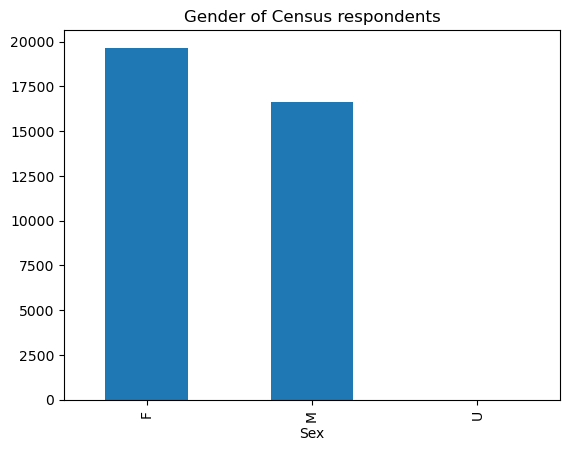

In [33]:
df['Sex'].value_counts()[:10].plot(kind='bar', title='Gender of Census respondents')

<Axes: title={'center': 'Type of Census respondents by Relationship'}, xlabel='Relat'>

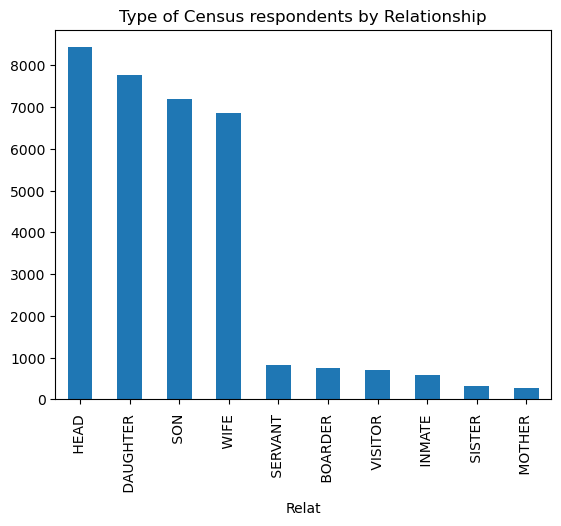

In [35]:
df['Relat'].value_counts()[:10].plot(kind='bar', title='Type of Census respondents by Relationship')

<Axes: title={'center': 'Relationship choices of Census respondents'}, ylabel='count'>

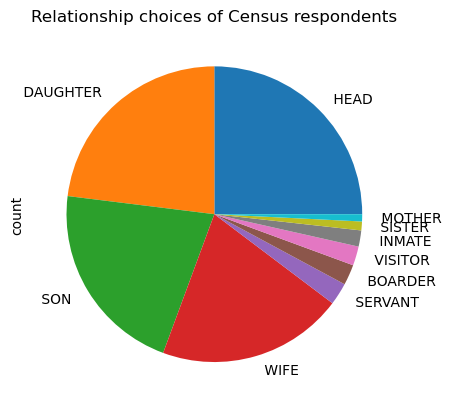

In [37]:
df['Relat'].value_counts()[:10].plot(kind='pie', title='Relationship choices of Census respondents')

<Axes: title={'center': 'Relationship choices of Census respondents'}, ylabel='Relat'>

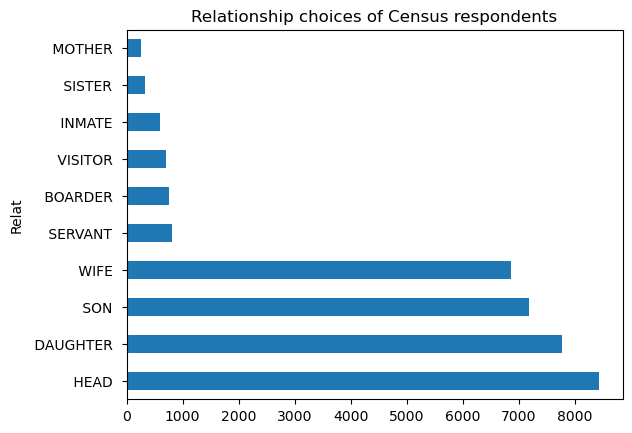

In [39]:
df['Relat'].value_counts()[:10].plot(kind='barh', title='Relationship choices of Census respondents')

To save any of the output charts for use in essays or papers, we can use the following code


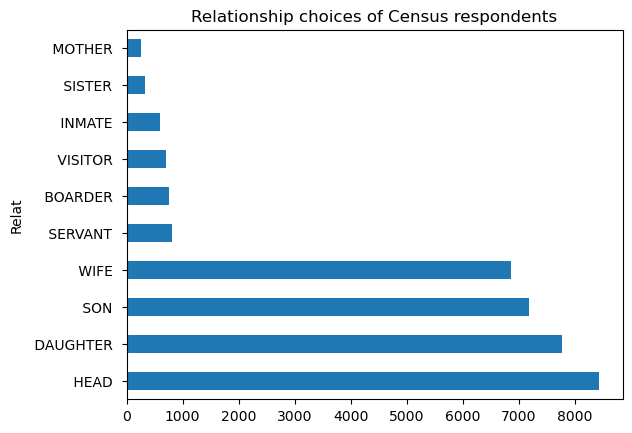

In [42]:
chart = df['Relat'].value_counts()[:10].plot(kind='barh', title='Relationship choices of Census respondents')
chart.figure.savefig('Relationships1921chart.pdf')

# Basic filters 

In [46]:
women_filter = df['Sex']=='F'

In [48]:
census_women = df[women_filter]

In [50]:
census_women.head()[:10]

,Parish,imageREF,Cond,Relat,Sex,Age,Occ,Occode,Employer,EmployerCode,Bpstring,BpCmty,InstName,LatLong,recid,hid
0,WANSTEAD,GBC/1921/RG15/08557/0945/02,MARRIED,WIFE,F,38,HOME DUTIES,788,-,999999,"MIDDLESEX, ISLINGTON",ISLINGTON,-,"51.5635,0.0375",11983239,2888214
1,WANSTEAD,GBC/1921/RG15/08558/0005/10,WIDOWED,OFFICER,F,32,CHILDRENS ATTENDANT,109,WEST HAM BOARD OF GUARDIANS,998,"NORTHAMPTONSHIRE, NORTHAMPTON",NORTHAMPTON,WEST HAM UNION CHILDREN'S HOUSES ALDERSBROOK...,"51.5631,0.0298798",11983301,2888228
2,WANSTEAD,GBC/1921/RG15/08558/0010/10,-,INMATE,F,13,-,999999,-,999999,"ESSEX, CANNING TOWN",CANNING TOWN,WEST HAM UNION CHILDREN'S HOUSES ALDERSBROOK...,"51.5631,0.0298798",11983371,2888228
3,WANSTEAD,GBC/1921/RG15/08558/0011/08,-,INMATE,F,7,-,999999,-,999999,"ESSEX, CANNING TOWN",CANNING TOWN,WEST HAM UNION CHILDREN'S HOUSES ALDERSBROOK...,"51.5631,0.0298798",11983384,2888228
14,WANSTEAD,GBC/1921/RG15/08558/0040/15,-,INMATE,F,14,-,999999,-,999999,"YORKSHIRE, BARNSLEY",BARNSLEY,ROYAL INFANT ORPHANAGE WOODFORD ROAD WANSTEAD,"51.5879,0.0216",11983738,2888229


In [52]:
census_women.nunique()

Parish              2
imageREF        19653
Cond                6
Relat             154
Sex                 1
Age                96
Occ              2264
Occode            241
Employer         3359
EmployerCode      132
Bpstring         5959
BpCmty           1556
InstName            9
LatLong           180
recid           19653
hid              8656
dtype: int64

In [54]:
census_women['Relat'].value_counts()

Relat
DAUGHTER                  7739
WIFE                      6849
HEAD                      1150
SERVANT                    800
VISITOR                    479
                          ... 
CHILD NURSE                  1
SUB-TENANT                   1
NEPHEW'S DAUGHTER            1
WIFE, DAUGHTER-IN-LAW        1
GREAT AUNT                   1
Name: count, Length: 154, dtype: int64

In [56]:
men_filter = df['Sex']=='M'

In [58]:
census_men = df[men_filter]

In [60]:
census_men['Relat'].value_counts()

Relat
HEAD                  7270
SON                   7153
BOARDER                426
INMATE                 324
VISITOR                226
                      ... 
BOARDER, HUSBAND         1
TEMPORARY BOARDER        1
LODGER'S SON             1
VISITOR, COUSIN          1
STEP-FATHER              1
Name: count, Length: 94, dtype: int64

In [62]:
age_filter = df['Age']>=14

In [64]:
df[age_filter]

,Parish,imageREF,Cond,Relat,Sex,Age,Occ,Occode,Employer,EmployerCode,Bpstring,BpCmty,InstName,LatLong,recid,hid
0,WANSTEAD,GBC/1921/RG15/08557/0945/02,MARRIED,WIFE,F,38,HOME DUTIES,788,-,999999,"MIDDLESEX, ISLINGTON",ISLINGTON,-,"51.5635,0.0375",11983239,2888214
1,WANSTEAD,GBC/1921/RG15/08558/0005/10,WIDOWED,OFFICER,F,32,CHILDRENS ATTENDANT,109,WEST HAM BOARD OF GUARDIANS,998,"NORTHAMPTONSHIRE, NORTHAMPTON",NORTHAMPTON,WEST HAM UNION CHILDREN'S HOUSES ALDERSBROOK...,"51.5631,0.0298798",11983301,2888228
6,WANSTEAD,GBC/1921/RG15/08558/0017/15,-,INMATE,M,15,-,999999,-,999999,"ESSEX, WALHAMSTON",-,WEST HAM UNION CHILDREN'S HOUSES ALDERSBROOK...,"51.5631,0.0298798",11983481,2888228
7,WANSTEAD,GBC/1921/RG15/08558/0019/07,-,INMATE,M,14,-,999999,-,999999,NEAR IRELAND,-,WEST HAM UNION CHILDREN'S HOUSES ALDERSBROOK...,"51.5631,0.0298798",11983503,2888228
14,WANSTEAD,GBC/1921/RG15/08558/0040/15,-,INMATE,F,14,-,999999,-,999999,"YORKSHIRE, BARNSLEY",BARNSLEY,ROYAL INFANT ORPHANAGE WOODFORD ROAD WANSTEAD,"51.5879,0.0216",11983738,2888229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36277,WANSTEAD,GBC/1921/RG15/08557/0095/02,MARRIED,WIFE,F,44,HOUSEHOLD DUTIES,788,-,999999,"ESSEX, BARKING",BARKING,-,"51.5635,0.0375",11981621,2887790
36279,WANSTEAD,GBC/1921/RG15/08557/0159/04,SINGLE,VISITOR,F,52,PHOTOGRAPHER,75,OWN ACCOUNT,88888,"SUFFOLK, GREAT BARTON",GREAT BARTON,-,"51.5635,0.042",11981751,2887821
36280,WANSTEAD,GBC/1921/RG15/08557/0169/03,SINGLE,DAUGHTER,F,15,-,999999,-,999999,"ESSEX, EASTHAM",EAST HAM,-,"51.5635,0.042",11981771,2887826
36281,WANSTEAD,GBC/1921/RG15/08557/0175/02,MARRIED,WIFE,F,40,HOUSEHOLD DUTIES,788,-,999999,NEW ZEALAND,-,-,"51.5635,0.042",11981780,2887829


If you want to export any of the filtered datasets there is a simple way to output a dataframe to .csv.

In [68]:
census_women.to_csv("1921censuswomen.csv", encoding='utf-8', index=False)